# DGBDrank Analísis
### Relación entre la BRF y la DGBDrank

La función Beta Rank Function (BRF) se define como

$$
x(r)=A\frac{(1-u)^b}{u^a},
$$

donde

$$
u=\frac{r}{N+1}.
$$

Sustituyendo en la expresión anterior,

$$
x(r)
=
A\frac{\left(1-\frac{r}{N+1}\right)^b}
{\left(\frac{r}{N+1}\right)^a}.
$$

Como

$$
1-\frac{r}{N+1}
=
\frac{N+1-r}{N+1},
$$

se obtiene

$$
x(r)
=
A
\frac{\left(\frac{N+1-r}{N+1}\right)^b}
{\left(\frac{r}{N+1}\right)^a}
=
A(N+1)^{a-b}
\frac{(N+1-r)^b}{r^a}.
$$

Por otra parte, la Discrete Generalized Beta Distribution rank (DGBDrank) se define como

$$
x(r)=A\frac{(N+1-r)^b}{r^a}.
$$

Por lo tanto,

$$
\mathrm{BRF}(r)
=
(N+1)^{a-b}\,
\mathrm{DGBD}(r).
$$

La BRF y la DGBDrank sólo difieren por un factor constante de escala. 

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
from scipy.optimize import least_squares
from scipy.special import betaln, gammaln

In [20]:
@njit
def BRF(N, A, a, b, normalizar=False):

    x = np.empty(N)

    for i in range(N):
        r = i + 1
        u = r / (N + 1)

        x[i] = A * ((1 - u) ** b) / (u ** a)

    if normalizar:
        x /= np.sum(x)

    return x


@njit
def DGBD(N, A, a, b,
         equivalente_BRF=False,
         normalizar=False):

    x = np.empty(N)

    pref = (N + 1) ** (a - b)

    for i in range(N):

        r = i + 1

        if equivalente_BRF:

            x[i] = (
                A
                * pref
                * ((N + 1 - r) ** b)
                / (r ** a)
            )

        else:

            x[i] = (
                A
                * ((N + 1 - r) ** b)
                / (r ** a)
            )

    if normalizar:
        x /= np.sum(x)

    return x

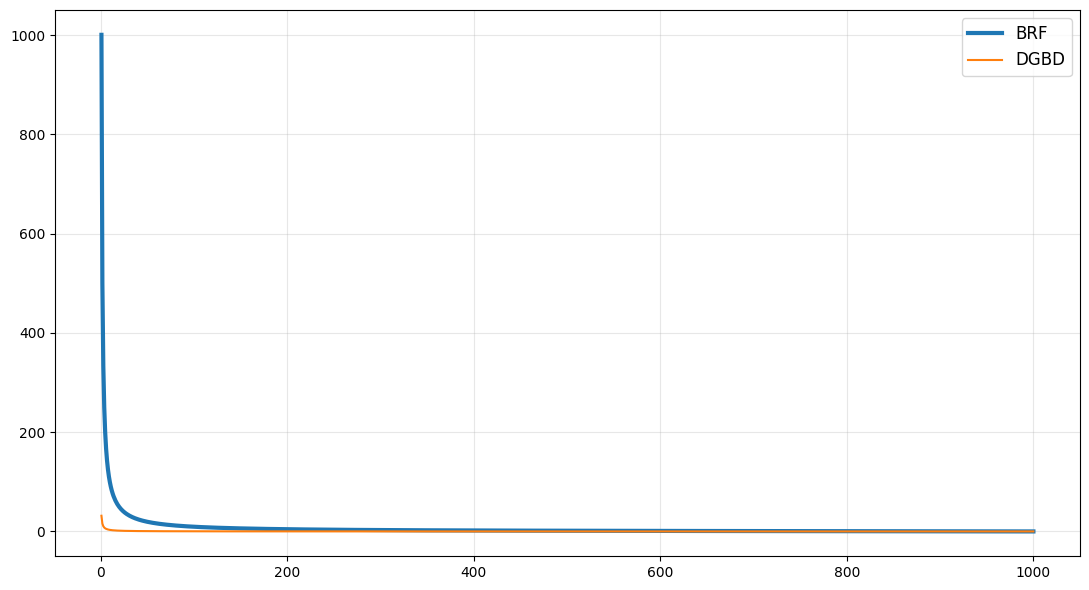

In [21]:

N = 1000
A = 1
a = 1
b = 0.5

x = BRF(N, A, a, b)
y = DGBD(N, A, a, b)

r = np.arange(1, N + 1)

plt.figure(figsize=(11, 6))

plt.plot(r, x, label="BRF", linewidth=3)
plt.plot(r, y, label="DGBD")

plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


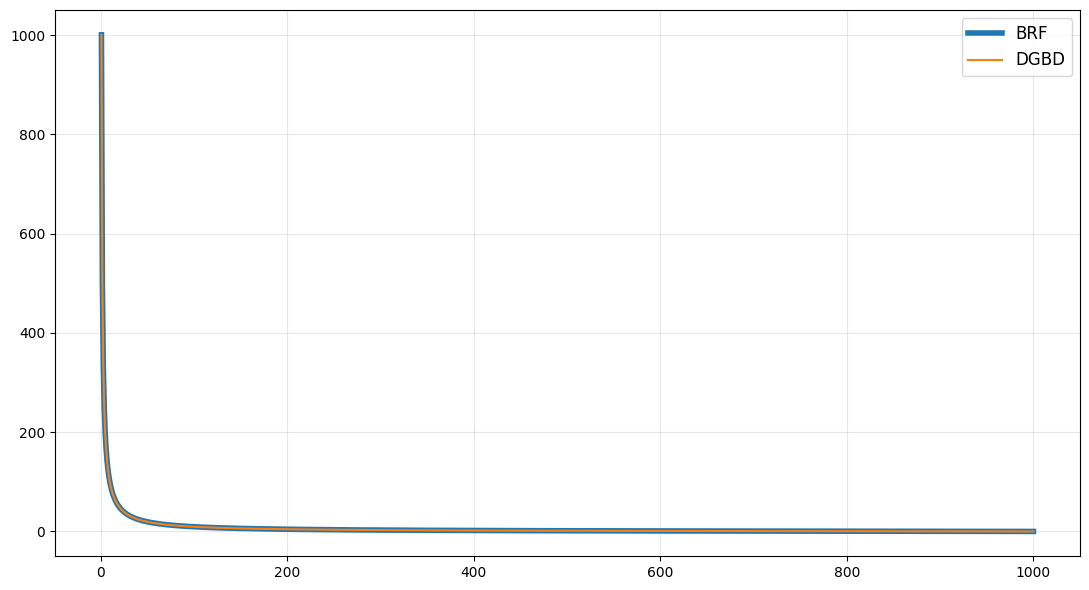

In [22]:

N = 1000
A = 1
a = 1
b = 0.5

x = BRF(N, A, a, b)
y = DGBD(N, A, a, b, True)

r = np.arange(1, N + 1)

plt.figure(figsize=(11, 6))

plt.plot(r, x, label="BRF", linewidth=4)
plt.plot(r, y, label="DGBD")

plt.grid(True, which="both", alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


### Expresión teórica de los cumulantes

A partir de la función característica asociada a la BRF se obtienen las siguientes expresiones teóricas para los primeros cuatro cumulantes:

$$
k_1=\ln(A)+a-b,
$$

$$
k_2=(a-b)^2+\frac{\pi^2}{3}ab,
$$

$$
k_3=2\zeta(3)(a^3-b^3)+2(\zeta(3)-1)(b-a)^3,
$$

$$
k_4=\frac{\pi^4}{15}\left(a^4+b^4-(b-a)^4\right)+6(b-a)^4,
$$

donde 

$$
\zeta(3)\approx 1.202056903.
$$

Las expresiones anteriores se derivan utilizando la parametrización continua de la BRF,

$$
x(r)=A\frac{(1-u)^b}{u^a},
\qquad
u=\frac{r}{N+1}.
$$

Sin embargo, cuando se utiliza la parametrización DGBD,

$$
x(r)=A\frac{(N+1-r)^b}{r^a},
$$

la amplitud efectiva cambia debido a la relación

$$
\mathrm{BRF}(r)=(N+1)^{a-b}\,\mathrm{DGBD}(r).
$$

Por esta razón, el primer cumulante debe modificarse para absorber dicho factor de escala. En ese caso se utiliza

$$
k_1^{\#}
=
\ln(A)
+
\frac{b-a}{N}\ln\Gamma(N+1).
$$

Los cumulantes restantes permanecen inalterados, ya que el cambio entre BRF y DGBDrank únicamente introduce una corrección multiplicativa global que afecta exclusivamente al primer cumulante.

In [23]:
def cumulantes_teoricos(N, A, a, b,f = False):                              #Cambiar f a true para caso BRF o DGBD con pref = (N + 1) ** (a - b) 
    zeta3 = 1.202056903159594
    if f == True:
        k1 = np.log(A) + a - b 
    else:
        k1 = np.log(A) + ((b - a) / N) * gammaln(N + 1)
    k2 = (a - b) ** 2 + (np.pi**2 / 3) * a * b
    k3 = 2 * zeta3 * (a**3 - b**3) + 2 * (zeta3 - 1) * (b - a) ** 3
    k4 = (np.pi**4 / 15) * (a**4 + b**4 - (b - a) ** 4) + 6 * (b - a) ** 4

    return np.array([k1, k2, k3, k4])

In [24]:
@njit
def cumulantes_empiricos(x):
    N = len(x)

    # log
    z = np.empty(N)
    for i in range(N):
        z[i] = np.log(x[i])

    # media
    k1 = 0.0
    for i in range(N):
        k1 += z[i]
    k1 /= N

    # momentos centrales
    m2 = 0.0
    m3 = 0.0
    m4 = 0.0

    for i in range(N):
        dz = z[i] - k1
        dz2 = dz * dz
        m2 += dz2
        m3 += dz2 * dz
        m4 += dz2 * dz2

    m2 /= N
    m3 /= N
    m4 /= N

    k2 = m2
    k3 = m3
    k4 = m4 - 3 * m2 * m2

    return np.array([k1, k2, k3, k4])

In [25]:
def experimento(n_runs=50, B = True):

    resultados = []
    N = 1_000
    for i in range(n_runs):
        # parámetros aleatorios
        A = np.random.uniform(10, 100)
        a = np.random.uniform(0.1, 1.0)
        b = np.random.uniform(0.1, 1.0)
        if B == True:
            x = BRF(N, A=A, a=a, b=b)
            k_theo = cumulantes_teoricos(N, A, a, b, f=True)
        else:
            x = DGBD(N, A=A, a=a, b=b)
            k_theo = cumulantes_teoricos(N, A, a, b)

        k_emp = cumulantes_empiricos(x)
        

        error = k_emp - k_theo
        rel_error = np.abs(error) / np.maximum(np.abs(k_theo), 1e-12)

        resultados.append((k_emp, k_theo, error, rel_error))

    return resultados


In [26]:
def plot_results(resultados):

    k_emp = np.array([r[0] for r in resultados])
    k_theo = np.array([r[1] for r in resultados])
    rel = np.array([r[3] for r in resultados])

    labels = ["k1", "k2", "k3", "k4"]

    # -------- scatter ----------
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i, ax in enumerate(axes):
        ax.scatter(k_theo[:, i], k_emp[:, i], s=10)

        mn = min(k_theo[:, i].min(), k_emp[:, i].min())
        mx = max(k_theo[:, i].max(), k_emp[:, i].max())
        ax.plot([mn, mx], [mn, mx], "r--")

        ax.set_title(labels[i])
        ax.set_xlabel("teórico")
        ax.set_ylabel("empírico")
        ax.grid(True)

    plt.suptitle("Empírico vs Teórico ")
    plt.tight_layout()
    plt.show()

    # -------- promedio de errores ----------
    mean_rel = np.mean(rel, axis=0)

    print("\nPromedio de error relativo:")
    for lab, err in zip(labels, mean_rel):
        print(f"{lab}: {err:.6e}")

    # -------- error relativo ----------
    plt.figure(figsize=(8, 4))
    plt.boxplot(rel, labels=labels, showmeans=True)
    plt.yscale("log")
    plt.title("Error relativo")
    plt.grid(True, which="both")
    plt.show()

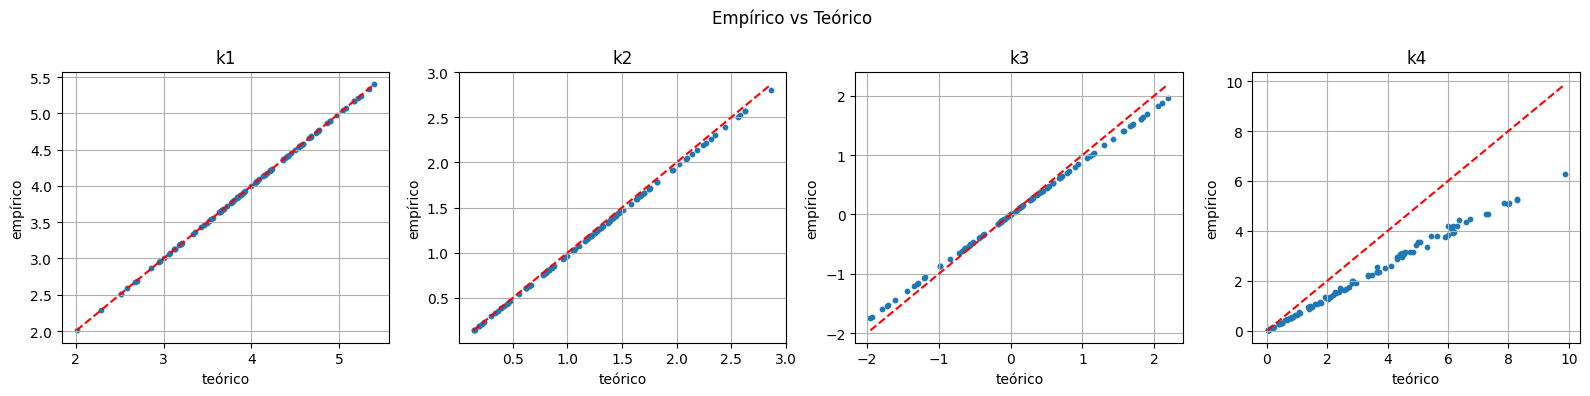


Promedio de error relativo:
k1: 2.498677e-04
k2: 2.343256e-02
k3: 1.066150e-01
k4: 3.379366e-01


C:\Users\PC BULLOCK\AppData\Local\Temp\ipykernel_28188\504783017.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rel, labels=labels, showmeans=True)


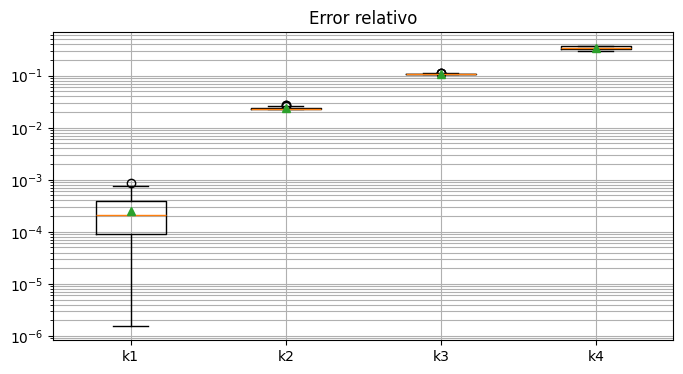

In [27]:
resultados = experimento(n_runs=100)    #Error caso BRF
plot_results(resultados)

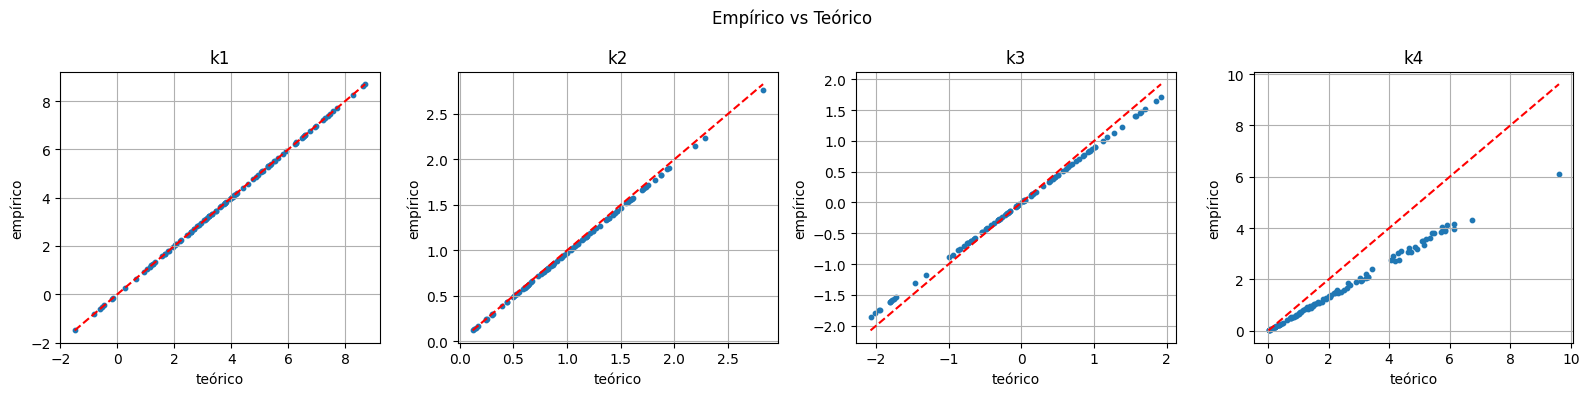


Promedio de error relativo:
k1: 9.125519e-16
k2: 2.360613e-02
k3: 1.068128e-01
k4: 3.339489e-01


C:\Users\PC BULLOCK\AppData\Local\Temp\ipykernel_28188\504783017.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(rel, labels=labels, showmeans=True)


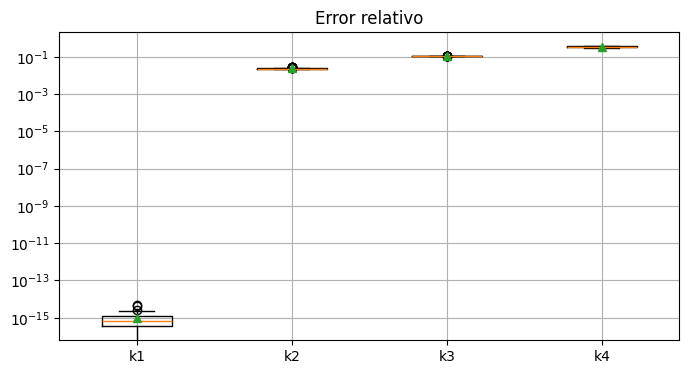

In [28]:
resultados = experimento(n_runs=100, B=False)  #Error caso DGBD
plot_results(resultados)

### Comparación entre la BRF y la DGBD mediante cumulantes

Para evaluar la consistencia de las expresiones teóricas obtenidas para los cumulantes, se compararon los valores teóricos con los cumulantes empíricos calculados a partir de datos sintéticos generados por la distribución correspondiente. La comparación se realizó utilizando el error relativo,

$$
\varepsilon_i =
\frac{|k_i^{\mathrm{emp}} - k_i^{\mathrm{teo}}|}
{|k_i^{\mathrm{teo}}|},
$$

el cual permite medir las discrepancias de forma independiente de la magnitud de cada cumulante.

Los errores relativos promedio obtenidos para la BRF fueron

| Cumulante | Error relativo promedio |
|------------|-----------------------:|
| $k_1$ | $2.58\times10^{-4}$ |
| $k_2$ | $2.35\times10^{-2}$ |
| $k_3$ | $1.07\times10^{-1}$ |
| $k_4$ | $3.36\times10^{-1}$ |

Mientras que para la parametrización DGBD, utilizando la corrección correspondiente en el primer cumulante, se obtuvo

| Cumulante | Error relativo promedio |
|------------|-----------------------:|
| $k_1$ | $7.76\times10^{-16}$ |
| $k_2$ | $2.36\times10^{-2}$ |
| $k_3$ | $1.07\times10^{-1}$ |
| $k_4$ | $3.35\times10^{-1}$ |

Se observa que los errores asociados a $k_2$, $k_3$ y $k_4$ son prácticamente idénticos en ambas representaciones, lo cual era esperado debido a que la diferencia entre la BRF y la DGBD consiste únicamente en un factor de escala. Dicho factor afecta exclusivamente al primer cumulante.

Sin embargo, al utilizar la parametrización DGBD junto con la expresión corregida para $k_1$, el error relativo del primer cumulante se reduce hasta el nivel de precisión numérica de la máquina ($\sim10^{-15}$), mientras que en la formulación BRF permanece varios órdenes de magnitud por encima de este valor.

Estos resultados indican que la parametrización DGBD proporciona una descripción más consistente desde el punto de vista numérico, reproduciendo con mayor precisión los cumulantes empíricos obtenidos a partir de los datos sintéticos. 

Se puede repetir el experimento utilizando el parametro de quivalencia en la función de la DGBD, sin embargo, los resultados se vuelven identicos a la BRF utilizando la expresión $$k_1=\ln(A)+a-b,$$ utilizar la $k_1$ modificada en dicho caso, destruye el ajuste, al igual que el utilizarlo con la BRF.

In [29]:
def experimento_convergencia(N_values, n_runs=20, B= False):                #Agregar B= True/False para elegir entre BRF o DGBD

    errores = {i: [] for i in range(4)}  # k1..k4

    for N in N_values:
        print(f"Procesando N={N}")

        rel_errors_runs = []

        for _ in range(n_runs):
            A = np.random.uniform(10, 100)
            a = np.random.uniform(0.1, 1.0)
            b = np.random.uniform(0.1, 1.0)

            if B == True:
                x = BRF(N, A=A, a=a, b=b)
                k_theo = cumulantes_teoricos(N, A, a, b, f=True)
            else:
                x = DGBD(N, A=A, a=a, b=b)
                k_theo = cumulantes_teoricos(N, A, a, b)
            
            k_emp = cumulantes_empiricos(x)
            

            rel_error = np.abs(k_emp - k_theo) / np.maximum(np.abs(k_theo), 1e-12)

            rel_errors_runs.append(rel_error)

        rel_errors_runs = np.array(rel_errors_runs)

        # guardar promedio (puedes cambiar a mediana si quieres robustez)
        for i in range(4):
            errores[i].append(np.mean(np.median(rel_errors_runs[:, i])))

    return errores

In [30]:
def plot_convergencia(N_values, errores):

    labels = ["k1", "k2", "k3", "k4"]

    plt.figure(figsize=(8, 5))

    for i in range(4):
        plt.plot(N_values, errores[i], marker="o", label=labels[i])

    plt.xscale("log")
    plt.yscale("log")

    plt.xlabel("N (tamaño de muestra)")
    plt.ylabel("Error relativo")
    plt.title("Convergencia de cumulantes")
    plt.legend()
    plt.grid(True, which="both")
    plt.show()


Procesando N=100
Procesando N=300
Procesando N=1000
Procesando N=3000
Procesando N=10000
Procesando N=30000
Procesando N=100000
Procesando N=300000
Procesando N=1000000
Procesando N=10000000


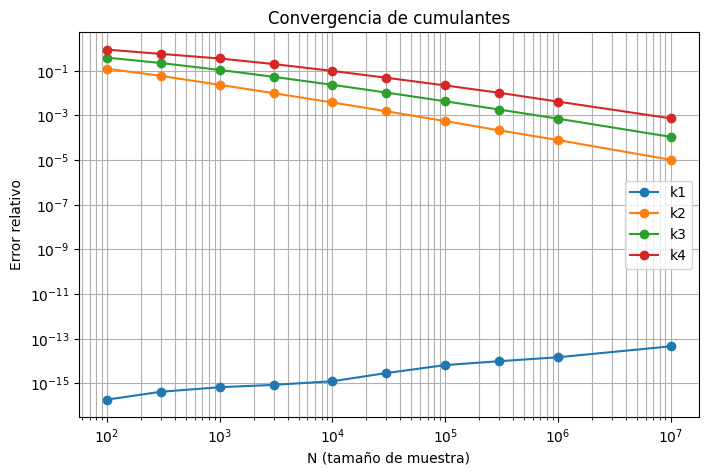

In [31]:
N_values = [                                                    #Caso DGBD
        100,
        300,
        1_000,
        3_000,
        10_000,
        30_000,
        100_000,
        300_000,
        1_000_000,
        10_000_000,
    ]

errores = experimento_convergencia(N_values, n_runs=30)
plot_convergencia(N_values, errores)

Procesando N=100
Procesando N=300
Procesando N=1000
Procesando N=3000
Procesando N=10000
Procesando N=30000
Procesando N=100000
Procesando N=300000
Procesando N=1000000
Procesando N=10000000


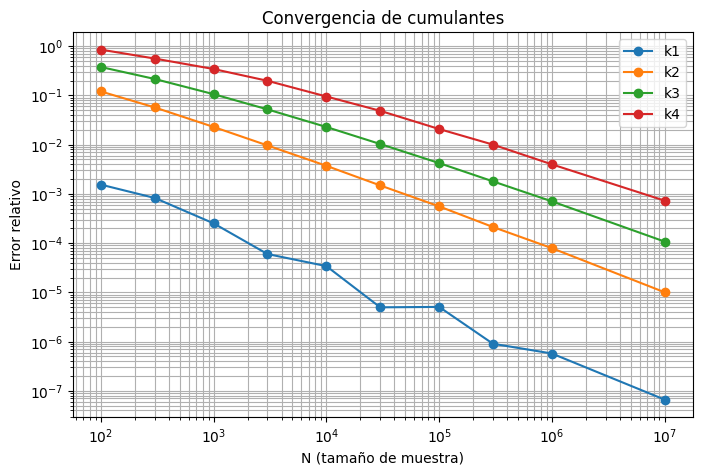

In [32]:
N_values = [                                                                #Caso BRF
        100,
        300,
        1_000,
        3_000,
        10_000,
        30_000,
        100_000,
        300_000,
        1_000_000,
        10_000_000,
    ]

errores = experimento_convergencia(N_values, n_runs=30, B=True)
plot_convergencia(N_values, errores)

### Convergencia de los errores relativos

Con el objetivo de analizar la estabilidad de los cumulantes teóricos, se estudió la evolución del error relativo al variar el tamaño del sistema $begin:math:text$N$end:math:text$. Para cada valor de $begin:math:text$N$end:math:text$ se generaron múltiples conjuntos de parámetros aleatorios $begin:math:text$\(A\,a\,b\)$end:math:text$, calculándose posteriormente los cumulantes empíricos y teóricos correspondientes.

El error relativo utilizado fue

$$
\varepsilon_i =
\frac{|k_i^{\mathrm{emp}}-k_i^{\mathrm{teo}}|}
{|k_i^{\mathrm{teo}}|}.
$$

Para cada tamaño de sistema se realizaron varias simulaciones independientes y se registró el comportamiento promedio de los errores asociados a los cuatro primeros cumulantes.

En el caso de la parametrización DGBD, el error relativo asociado al primer cumulante $begin:math:text$k\_1$end:math:text$ se mantiene típicamente del orden de

$$
10^{-15},
$$

valor que coincide con la precisión numérica esperada para números en doble precisión. Esto indica que la expresión teórica reproduce prácticamente de manera exacta el valor empírico de $k_1$.

Por esta razón, las pequeñas variaciones observadas en las curvas de convergencia de $k_1$ para la DGBD no deben interpretarse como discrepancias físicas o estadísticas significativas, sino como fluctuaciones originadas por los límites de precisión de la aritmética de punto flotante. En términos prácticos, estos errores son despreciables y pueden considerarse equivalentes a cero dentro de la precisión numérica del cálculo.

Los errores observados en los cumulantes de orden superior ($k_2$, $k_3$ y $k_4$) son mayores debido a que los cumulantes empíricos se calculan sobre sistemas de tamaño finito. En consecuencia, aparecen correcciones de tamaño finito asociadas a la discretización del rango y a la diferencia entre sumas finitas y sus correspondientes expresiones asintóticas.

Las expresiones teóricas utilizadas para los cumulantes se obtienen en el límite asintótico de la distribución. Por ello, a medida que $begin:math:text$N$end:math:text$ aumenta, las correcciones de tamaño finito se vuelven cada vez menos importantes y los cumulantes empíricos convergen hacia los valores teóricos.

En el límite ideal

$$
N \rightarrow \infty,
$$

se espera que dichas correcciones desaparezcan completamente, de modo que

$$
k_i^{\mathrm{emp}}
\longrightarrow
k_i^{\mathrm{teo}},
\qquad i=1,2,3,4.
$$

Por lo tanto, en el caso hipotético de un sistema infinito, los valores teóricos representarían exactamente los cumulantes de la distribución y el error relativo tendería a cero para todos los órdenes. Las discrepancias observadas para valores finitos de $begin:math:text$N$end:math:text$ deben interpretarse entonces como efectos de tamaño finito y no como una inconsistencia de las expresiones teóricas.

In [33]:
def fit_rank(dat, usar_BRF=False):

    dat = np.asarray(dat, float)

    y = np.sort(dat)[::-1]
    r = np.arange(1, len(y) + 1)

    N = len(y)

    mask = y > 0
    y, r = y[mask], r[mask]

    # =====================================================
    # Inicialización lineal
    # =====================================================
    if usar_BRF:

        X1 = np.log(1 - r / (N + 1))
        X2 = np.log(r / (N + 1))

    else:  # DGBD

        X1 = np.log(N + 1 - r)
        X2 = np.log(r)

    Y = np.log(y)

    M = np.column_stack([
        np.ones_like(X1),
        X1,
        -X2
    ])

    coef, *_ = np.linalg.lstsq(M, Y, rcond=None)

    A0 = np.exp(coef[0])
    b0 = coef[1]
    a0 = coef[2]

    def model(p):

        A, a, b = p

        if usar_BRF:

            pred = A * (
                (1 - r / (N + 1))**b
            ) / (
                (r / (N + 1))**a
            )

        else:  # DGBD

            pred = A * (
                (N + 1 - r)**b
            ) / (
                r**a
            )

        return np.log(pred) - np.log(y)

    sol = least_squares(
        model,
        (A0, a0, b0),
        method="lm"
    )

    return sol.x

In [ ]:
def experimento_grid(N=5000, na=60, nb=60, usar_BRF=True):

    A = 10.0

    a_vals = np.linspace(-10, 10, na)
    b_vals = np.linspace(-10, 10, nb)

    err_a = np.empty((na, nb))
    err_b = np.empty((na, nb))

    for i, a in enumerate(a_vals):
        for j, b in enumerate(b_vals):

            # -------------------------
            # Generar datos
            # -------------------------
            if usar_BRF:
                x = BRF(N, A, a, b)
            else:
                x = DGBD(N, A, a, b)

            # -------------------------
            # Ajustar con el mismo modelo
            # -------------------------
            A_P, a_P, b_P = fit_rank(
                x,
                usar_BRF=usar_BRF
            )

            # -------------------------
            # Errores relativos
            # -------------------------
            ea = (
                np.abs((a - a_P) / a)
                if abs(a) > 1e-12
                else abs(a - a_P)
            )

            eb = (
                np.abs((b - b_P) / b)
                if abs(b) > 1e-12
                else abs(b - b_P)
            )

            err_a[i, j] = ea
            err_b[i, j] = eb

    return a_vals, b_vals, err_a, err_b

In [42]:
def plot_errores_grid(a_vals, b_vals, err_a, err_b, usar_BRF=True):

    modelo = "BRF" if usar_BRF else "DGBD"

    # ========================================================
    # error en a
    # ========================================================
    plt.figure(figsize=(10, 7))

    plt.imshow(
        np.log10(err_a + 1e-16),
        origin="lower",
        aspect="auto",
        extent=[
            b_vals.min(),
            b_vals.max(),
            a_vals.min(),
            a_vals.max()
        ],
    )

    plt.colorbar(label=r"$\log_{10}$ error relativo en $a$")

    plt.xlabel("b")
    plt.ylabel("a")
    plt.title(f"{modelo}: error de ajuste en a")

    plt.tight_layout()
    plt.show()

    # ========================================================
    # error en b
    # ========================================================
    plt.figure(figsize=(10, 7))

    plt.imshow(
        np.log10(err_b + 1e-16),
        origin="lower",
        aspect="auto",
        extent=[
            b_vals.min(),
            b_vals.max(),
            a_vals.min(),
            a_vals.max()
        ],
    )

    plt.colorbar(label=r"$\log_{10}$ error relativo en $b$")

    plt.xlabel("b")
    plt.ylabel("a")
    plt.title(f"{modelo}: error de ajuste en b")

    plt.tight_layout()
    plt.show()

C:\Users\PC BULLOCK\AppData\Local\Temp\ipykernel_28188\1065280404.py:60: RuntimeWarning: invalid value encountered in log
  return np.log(pred) - np.log(y)


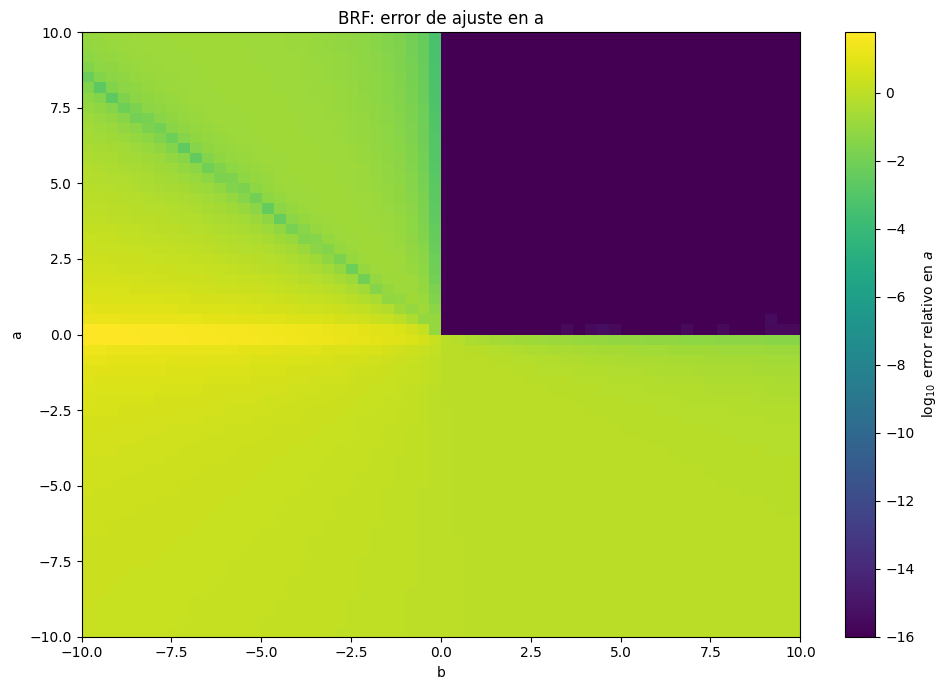

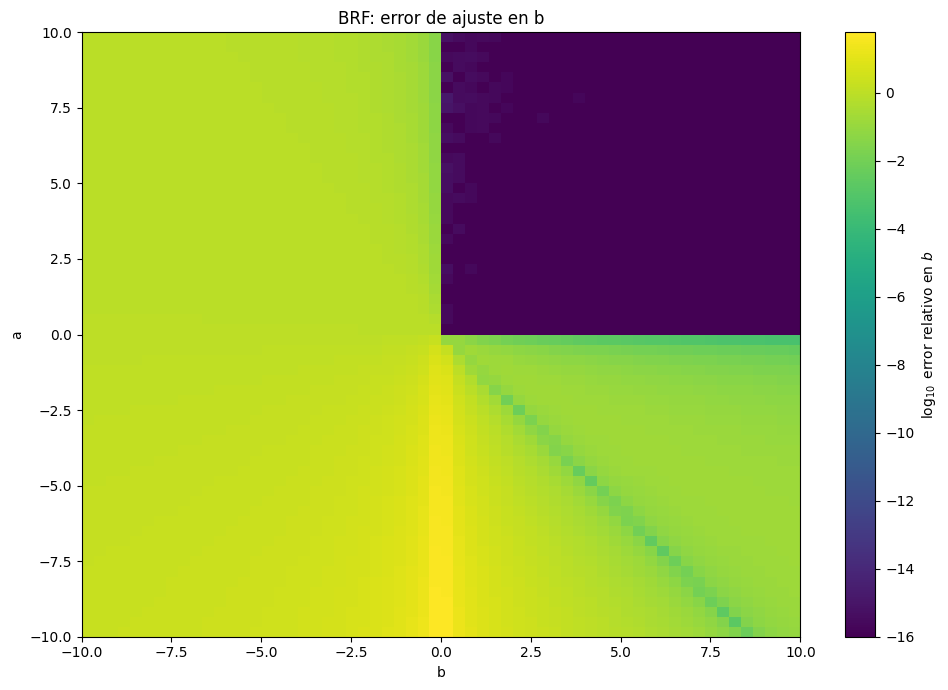

In [43]:
a_vals, b_vals, err_a, err_b = experimento_grid(
    N=5000,
    usar_BRF=True
)

plot_errores_grid(
    a_vals,
    b_vals,
    err_a,
    err_b,
    usar_BRF=True
)

C:\Users\PC BULLOCK\AppData\Local\Temp\ipykernel_28188\1065280404.py:60: RuntimeWarning: invalid value encountered in log
  return np.log(pred) - np.log(y)


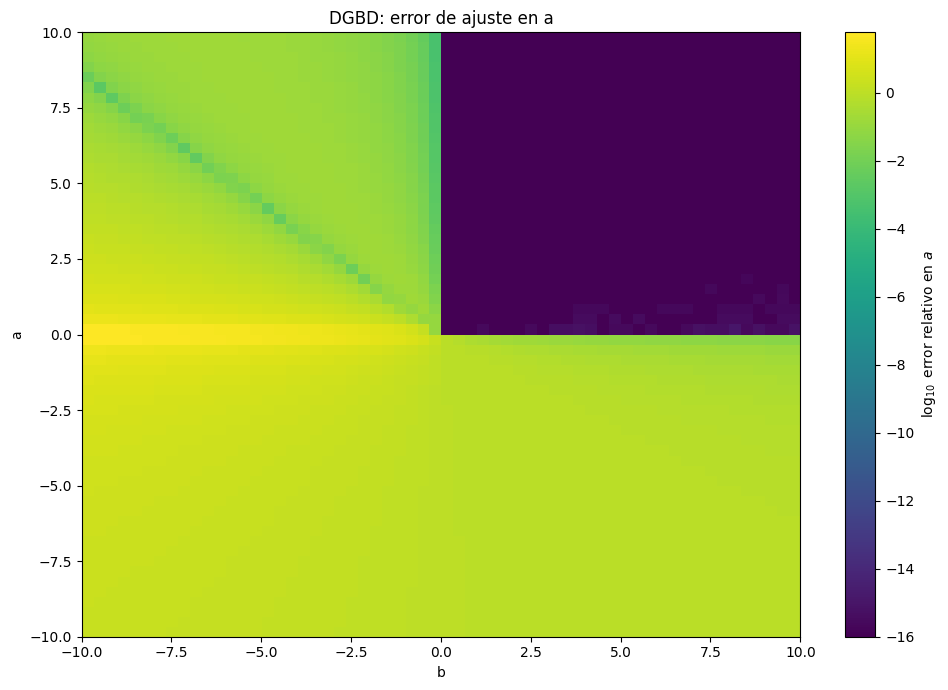

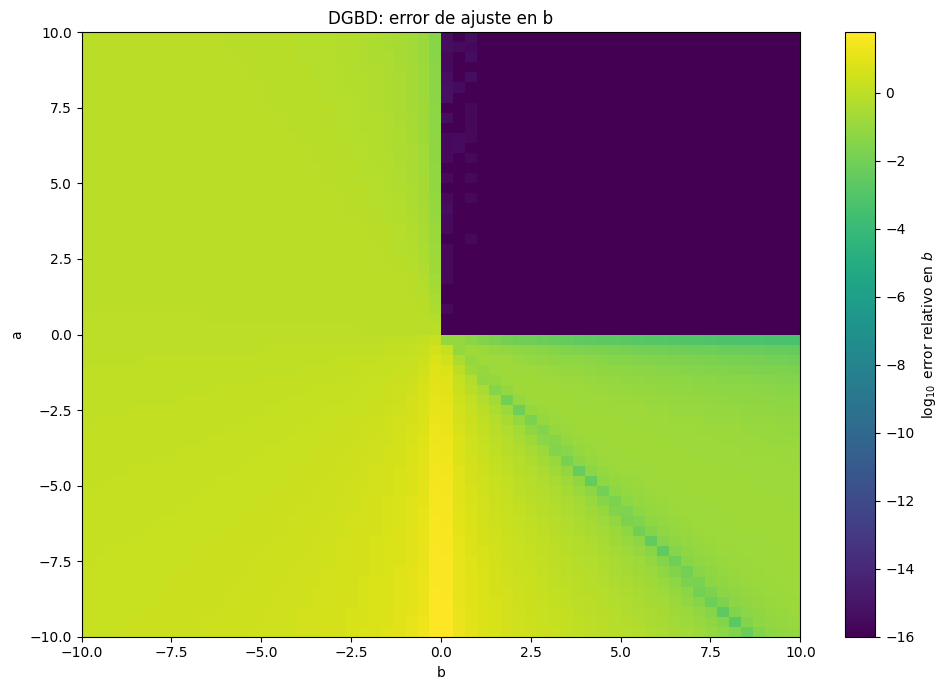

In [37]:
a_vals, b_vals, err_a, err_b = experimento_grid(
    N=5000,
    usar_BRF=False
)

plot_errores_grid(
    a_vals,
    b_vals,
    err_a,
    err_b,
    usar_BRF=False
)

### Error de ajuste para la BRF y la DGBD

Los mapas de error relativo muestran que la calidad del ajuste es esencialmente equivalente para las parametrizaciones BRF y DGBD. Este resultado era esperado, ya que ambas expresiones describen la misma familia funcional y difieren únicamente por un factor de escala dependiente de $N$, el cual puede absorberse completamente en el parámetro de amplitud $A$.

En consecuencia, los exponentes $a$ y $b$ recuperados mediante el procedimiento de ajuste presentan errores prácticamente indistinguibles para ambas representaciones. Esto confirma que la elección entre BRF y DGBD no afecta significativamente la estimación de los exponentes, sino únicamente la forma en que se parametriza la amplitud.

### Regiones diagonales y restricciones de normalización

En los mapas de error pueden observarse bandas diagonales donde la calidad del ajuste se degrada significativamente. Estas regiones corresponden a combinaciones de parámetros $(a,b)$ para las cuales la distribución deja de satisfacer las condiciones requeridas para una normalización adecuada.

Es importante destacar que los experimentos realizados hasta este punto se construyeron utilizando parámetros previamente seleccionados dentro de regiones conocidas como admisibles. Por esta razón, los resultados obtenidos para los cumulantes y para la comparación entre teoría y simulación no se ven afectados por estas zonas problemáticas.

Sin embargo, al explorar sistemáticamente el espacio de parámetros mediante una malla bidimensional, aparecen naturalmente regiones donde la normalización deja de estar garantizada. En dichos casos la amplitud $A$ deja de representar una constante de normalización bien definida y el comportamiento numérico del ajuste puede deteriorarse.

### Normalización de la distribución

El siguiente paso natural consiste en incorporar explícitamente la normalización de la distribución. Para la DGBD esto implica definir

$$
p(r)=
\frac{1}{Z(a,b,N)}
\frac{(N+1-r)^b}{r^a},
$$

donde

$$
Z(a,b,N)
=
\sum_{r=1}^{N}
\frac{(N+1-r)^b}{r^a}
$$

es la constante de normalización.

De manera análoga, para la BRF se tendría

$$
p(r)=
\frac{1}{Z(a,b,N)}
\frac{\left(1-\frac{r}{N+1}\right)^b}
{\left(\frac{r}{N+1}\right)^a},
$$

con

$$
Z(a,b,N)
=
\sum_{r=1}^{N}
\frac{\left(1-\frac{r}{N+1}\right)^b}
{\left(\frac{r}{N+1}\right)^a}.
$$

Al imponer esta condición, el parámetro $A$ deja de ser libre y queda completamente determinado por la constante de normalización,

$$
A=\frac{1}{Z(a,b,N)}.
$$

### Consecuencias para el primer cumulante

Dado que los cumulantes de orden superior dependen únicamente de los exponentes $a$ y $b$, la normalización afecta exclusivamente al primer cumulante $k\_1$.

Para la DGBD, al sustituir la amplitud normalizada, el primer cumulante pasa a escribirse como

$$
k_1
=
-\ln Z(a,b,N)
+
\frac{b-a}{N}\,
\ln\Gamma(N+1),
$$

mientras que para la BRF se obtiene

$$
k_1
=
-\ln Z^*(a,b,N)
+
a-b.
$$

Los cumulantes $k_2$, $k_3$ y $k_4$ permanecen inalterados, ya que una transformación global de escala únicamente produce un desplazamiento aditivo en la función generadora de cumulantes y, por tanto, sólo modifica el primer cumulante.

En consecuencia, una vez incorporada la normalización, toda la información relacionada con la amplitud queda absorbida en la constante $Z(a,b,N)$, mientras que la estructura de los cumulantes de orden superior permanece exactamente igual.

### Condiciones de normalización para la BRF y la DGBD

Al imponer la condición de normalización, la distribución debe satisfacer

$$
\int_0^1 p(x)\,dx = 1,
$$

o, en el caso discreto,

$$
\sum_{r=1}^{N} p(r)=1.
$$

Para la BRF continua,

$$
p(x)
=
\frac{(1-x)^b x^{-a}}
{Z(a,b)},
\qquad x\in(0,1),
$$

donde

$$
Z(a,b)
=
\int_0^1
(1-x)^b x^{-a}\,dx.
$$

La convergencia de esta integral depende del comportamiento del integrando en los extremos del intervalo.

Cerca de $x=0$,

$$
(1-x)^b x^{-a}
\sim
x^{-a},
$$

por lo que la convergencia requiere

$$
-a>-1,
$$

es decir,

$$
a<1.
$$

Por otro lado, cerca de $x=1$,

$$
(1-x)^b x^{-a}
\sim
(1-x)^b,
$$

y la convergencia exige

$$
b>-1.
$$

Por tanto, la región de normalización para la BRF viene dada por

$$
a<1,
\qquad
b>-1.
$$

### Caso de la DGBD

La DGBD se define como

$$
f(r)
=
A
\frac{(N+1-r)^b}
{r^a}.
$$

Introduciendo la variable continua

$$
u=\frac{r}{N+1},
$$

se obtiene

$$
f(r)
=
A(N+1)^{\,b-a}
(1-u)^b u^{-a}.
$$

Salvo por el factor constante $(N+1)^{b-a}$, la dependencia funcional es exactamente la misma que en la BRF continua. En consecuencia, la constante de normalización en el límite continuo está gobernada por la misma integral

$$
Z(a,b)
=
\int_0^1
(1-u)^b u^{-a}\,du.
$$

El análisis de los extremos produce nuevamente las condiciones

$$
a<1,
\qquad
b>-1.
$$

Por lo tanto, tanto la BRF como la DGBD comparten exactamente la misma región de normalización.

### Implicaciones para los experimentos

Las condiciones

$$
a<1,
\qquad
b>-1
$$

delimitan la región donde la distribución puede interpretarse como una densidad de probabilidad bien definida en el límite continuo. Fuera de esta región, la constante de normalización diverge debido a singularidades en los extremos del intervalo.

Por esta razón, al trabajar con distribuciones normalizadas resulta natural restringir los experimentos a valores de $(a,b)$ que satisfagan estas desigualdades. Dentro de esta región los cumulantes normalizados están bien definidos y poseen una interpretación probabilística consistente, mientras que fuera de ella dejan de existir en el límite continuo.

In [38]:
def fit_rank_normalizado(dat, usar_BRF=False):

    dat = np.asarray(dat, float)

    y = np.sort(dat)[::-1]
    r = np.arange(1, len(y) + 1)

    N = len(y)

    mask = y > 0
    y, r = y[mask], r[mask]

    # =====================================================
    # Normalización de los datos
    # =====================================================
    y = y / np.sum(y)

    # =====================================================
    # Inicialización lineal
    # =====================================================
    if usar_BRF:

        X1 = np.log(1 - r / (N + 1))
        X2 = np.log(r / (N + 1))

    else:

        X1 = np.log(N + 1 - r)
        X2 = np.log(r)

    Y = np.log(y)

    M = np.column_stack([
        np.ones_like(X1),
        X1,
        -X2
    ])

    coef, *_ = np.linalg.lstsq(M, Y, rcond=None)

    b0 = coef[1]
    a0 = coef[2]

    # =====================================================
    # Proyectar semilla a región normalizable
    # =====================================================
    a0 = min(a0, 0.99)
    b0 = max(b0, -0.99)

    # =====================================================
    # Modelo normalizado
    # =====================================================
    def model(p):

        a, b = p

        if usar_BRF:

            pred = (
                (1 - r / (N + 1))**b
                /
                (r / (N + 1))**a
            )

        else:

            pred = (
                (N + 1 - r)**b
                /
                r**a
            )

        # normalización automática
        pred = pred / np.sum(pred)

        return np.log(pred) - np.log(y)

    sol = least_squares(
        model,
        x0=(a0, b0),
        bounds=(
            [-np.inf, -0.999999],   # a, b
            [ 0.999999,  np.inf]
        ),
        method="trf"
    )

    a_fit, b_fit = sol.x

    # =====================================================
    # Recuperar constante de normalización
    # =====================================================
    if usar_BRF:

        Z = np.sum(
            ((1 - r/(N + 1))**b_fit)
            /
            ((r/(N + 1))**a_fit)
        )

    else:

        Z = np.sum(
            ((N + 1 - r)**b_fit)
            /
            (r**a_fit)
        )

    

    return  a_fit, b_fit

In [46]:
def experimento_grid_normalizado(
    N=5000,
    na=60,
    nb=60,
    usar_BRF=True
):

    a_vals = np.linspace(-10, 10, na)
    b_vals = np.linspace(-10, 10, nb)

    err_a = np.empty((na, nb))
    err_b = np.empty((na, nb))

    for i, a in enumerate(a_vals):
        for j, b in enumerate(b_vals):

            # ---------------------------------
            # Generar distribución
            # ---------------------------------
            if usar_BRF:
                x = BRF(N, 1,a, b, normalizar=True)
            else:
                x = DGBD(N, 1, a, b, normalizar=True)

            # ---------------------------------
            # Normalizar
            # ---------------------------------
            Z = np.sum(x)
            x = x / Z

            # ---------------------------------
            # Ajustar
            # ---------------------------------
            a_P, b_P = fit_rank_normalizado(
                x,
                usar_BRF=usar_BRF
            )

            # ---------------------------------
            # Error relativo en a
            # ---------------------------------
            if abs(a) > 1e-12:
                ea = np.abs((a - a_P) / a)
            else:
                ea = np.abs(a - a_P)

            # ---------------------------------
            # Error relativo en b
            # ---------------------------------
            if abs(b) > 1e-12:
                eb = np.abs((b - b_P) / b)
            else:
                eb = np.abs(b - b_P)

            err_a[i, j] = ea
            err_b[i, j] = eb

    return a_vals, b_vals, err_a, err_b

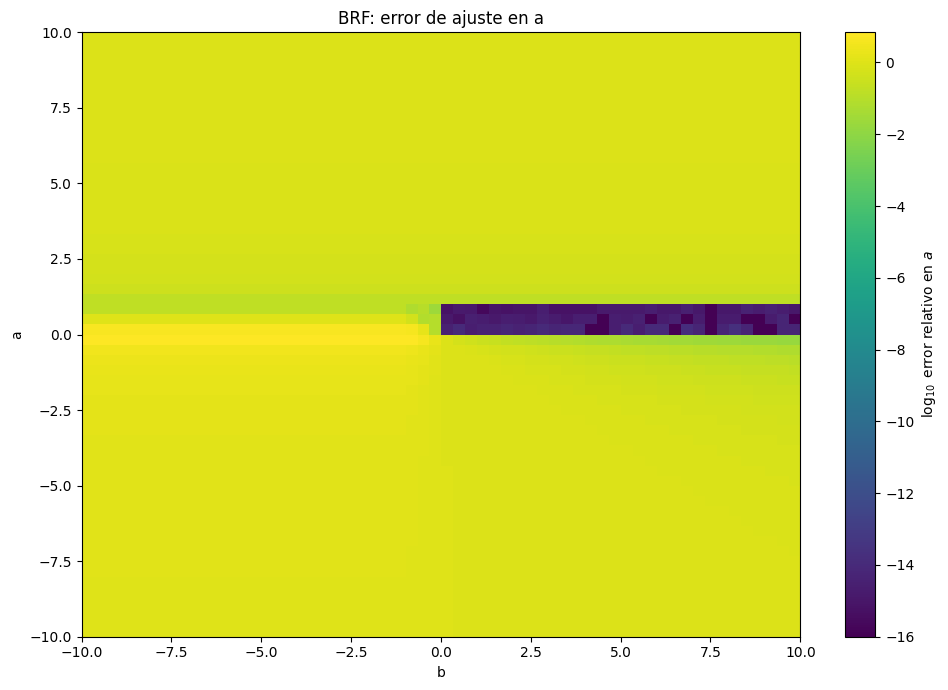

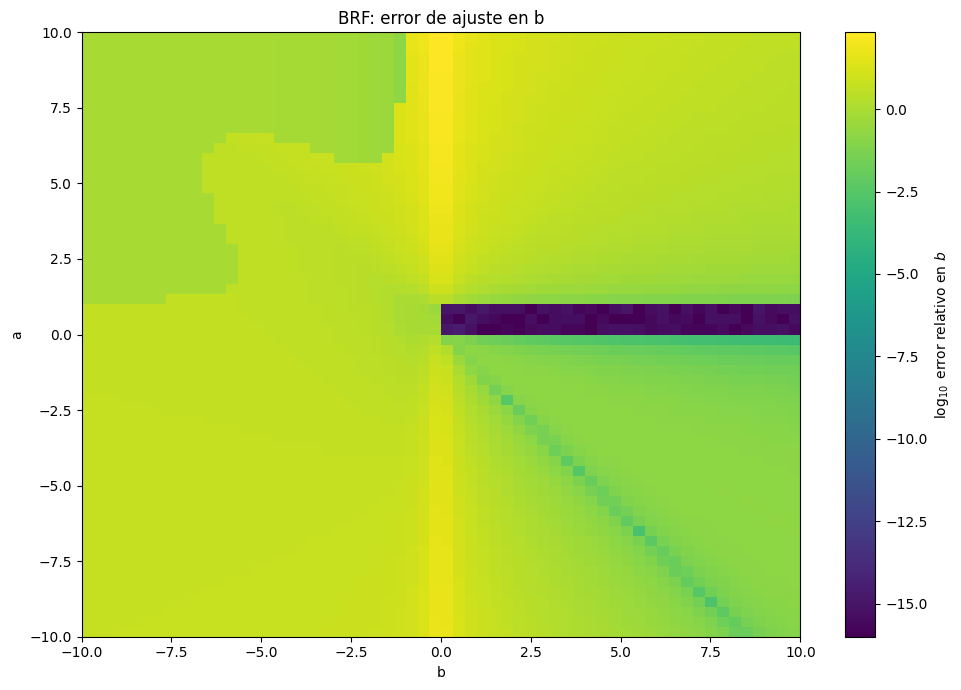

In [47]:
a_vals, b_vals, err_a, err_b = experimento_grid_normalizado(
    N=5000,
    usar_BRF=True
)

plot_errores_grid(
    a_vals,
    b_vals,
    err_a,
    err_b,
    usar_BRF=True
)

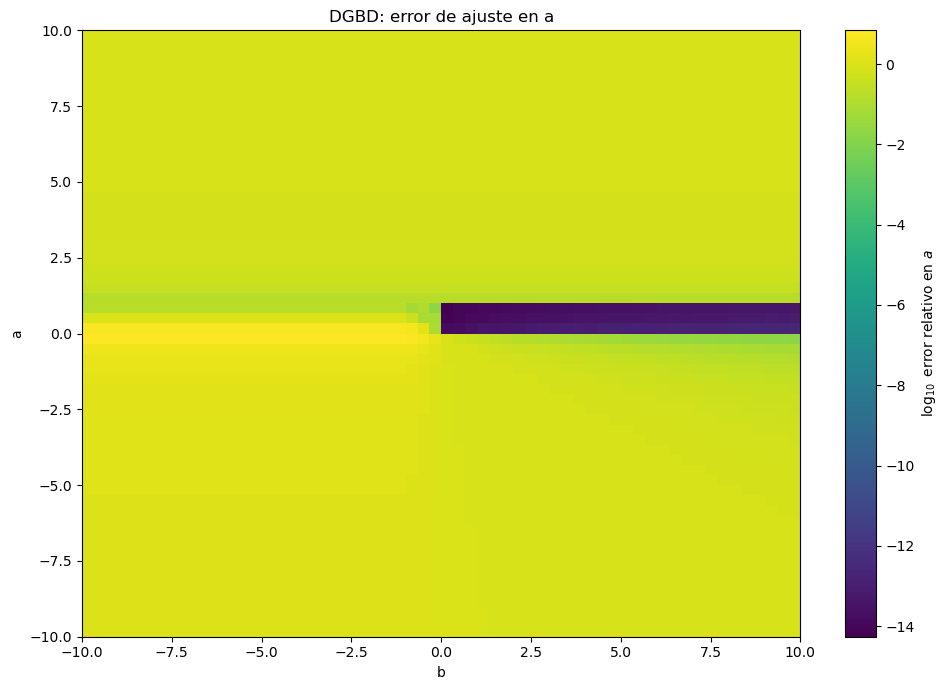

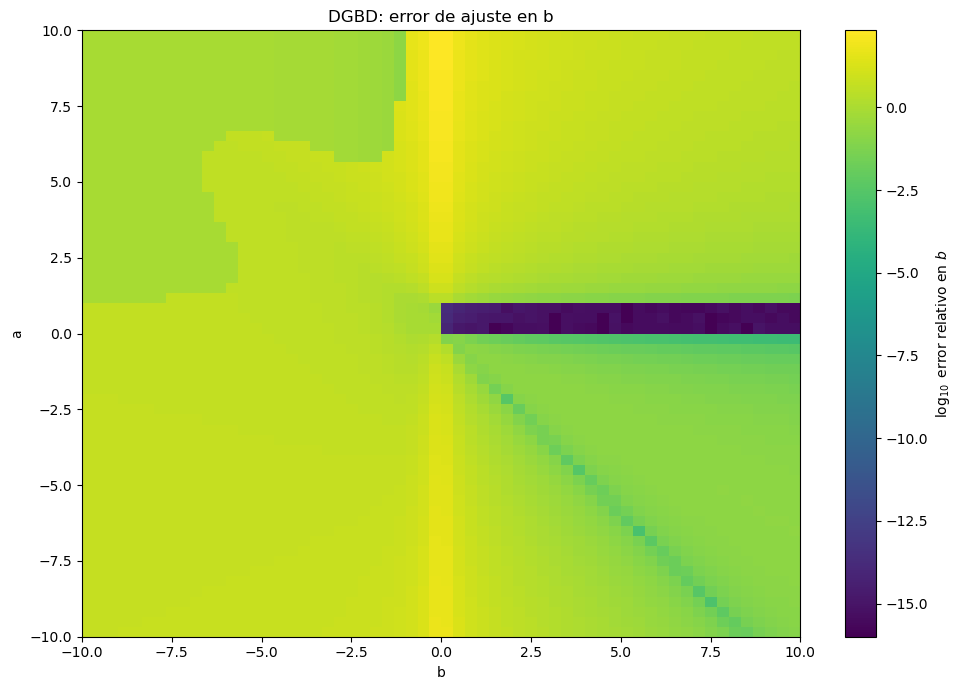

In [133]:
a_vals, b_vals, err_a, err_b = experimento_grid_normalizado(
    N=5000,
    usar_BRF=False
)

plot_errores_grid(
    a_vals,
    b_vals,
    err_a,
    err_b,
    usar_BRF=False
)

### Cambio de Levenberg–Marquardt a Trust Region Reflective

Inicialmente los ajustes se realizaron utilizando el algoritmo de Levenberg–Marquardt (LM),

$$
\min_{\theta}
\sum_i r_i(\theta)^2,
$$

debido a que está específicamente diseñado para problemas de mínimos cuadrados no lineales y suele presentar una convergencia rápida cuando los parámetros son libres y el punto inicial es razonablemente cercano a la solución.

Sin embargo, al introducir la normalización de la distribución aparecen restricciones teóricas sobre los parámetros,

$$
a < 1,
\qquad
b > -1,
$$

las cuales garantizan la existencia de una distribución normalizable en el límite continuo. Estas restricciones deben imponerse explícitamente durante el proceso de ajuste para evitar que el optimizador explore regiones no admisibles del espacio de parámetros.

El inconveniente es que el algoritmo de Levenberg–Marquardt no permite incorporar cotas sobre los parámetros. Por esta razón fue necesario sustituirlo por el método Trust Region Reflective (TRF), el cual sí admite restricciones de tipo

$$
l_i \le \theta_i \le u_i.
$$

En particular, se impusieron las cotas

$$
a < 1,
\qquad
b > -1,
$$

mediante

```python
bounds=(
    [-np.inf, -0.999999],
    [ 0.999999,  np.inf]
)
```

de forma que el algoritmo sólo explore la región compatible con la normalización.

Aunque LM suele ser ligeramente más rápido para problemas sin restricciones, TRF proporciona una mayor robustez cuando existen límites físicos o matemáticos sobre los parámetros. En este trabajo, la posibilidad de imponer las condiciones de normalización hace que TRF sea la elección natural para el ajuste de distribuciones normalizadas.

Por lo tanto, el cambio de LM a TRF no responde a una mejora en la calidad intrínseca del ajuste, sino a la necesidad de incorporar explícitamente las restricciones teóricas que surgen al normalizar la BRF y la DGBD.

In [ ]:
def experimento_convergencia_N(
    n_runs,
    usar_BRF=True,
    normalizado=False
):

    resultados = []

    # parámetros reales
    a = 0.7
    b = 0.5

    for i in range(1, n_runs + 1):

        N = i * 100

        # ===================================
        # Generar distribución
        # ===================================
        if usar_BRF:

            x = BRF(
                N,
                A=1.0,
                a=a,
                b=b,
                normalizar=normalizado
            )

        else:

            x = DGBD(
                N,
                A=1.0,
                a=a,
                b=b,
                normalizar=normalizado
            )

        # ===================================
        # Ajuste
        # ===================================
        if normalizado:

            a_P, b_P = fit_rank_normalizado(
                x,
                usar_BRF=usar_BRF
            )

        else:

            _, a_P, b_P = fit_rank(
                x,
                usar_BRF=usar_BRF
            )

        # ===================================
        # Errores relativos
        # ===================================
        err_a = np.abs((a - a_P) / a)

        err_b = np.abs((b - b_P) / b)

        resultados.append([
            N,
            err_a,
            err_b
        ])

    return np.array(resultados), (a, b)

In [136]:
def plot_convergencia_N(
    resultados,
    usar_BRF=True,
    normalizado=False
):

    N = resultados[:, 0]

    err_a = resultados[:, 1]

    err_b = resultados[:, 2]

    modelo = "BRF" if usar_BRF else "DGBD"

    if normalizado:
        modelo += " normalizada"

    plt.figure(figsize=(11, 6))

    plt.plot(
        N,
        np.abs(err_a),
        label=r'$|(a-a_P)/a|$',
        marker='s',
        markersize=4,
        linewidth=2,
        linestyle='--'
    )

    plt.plot(
        N,
        np.abs(err_b),
        label=r'$|(b-b_P)/b|$',
        marker='^',
        markersize=4,
        linewidth=2,
        linestyle=':'
    )

    plt.yscale("log")

    plt.xlabel("N", fontsize=13)

    plt.ylabel(
        "Error relativo absoluto",
        fontsize=13
    )

    plt.title(
        f"Convergencia del ajuste ({modelo})",
        fontsize=15
    )

    plt.grid(
        True,
        which="both",
        alpha=0.3
    )

    plt.legend(fontsize=12)

    plt.tight_layout()

    plt.show()

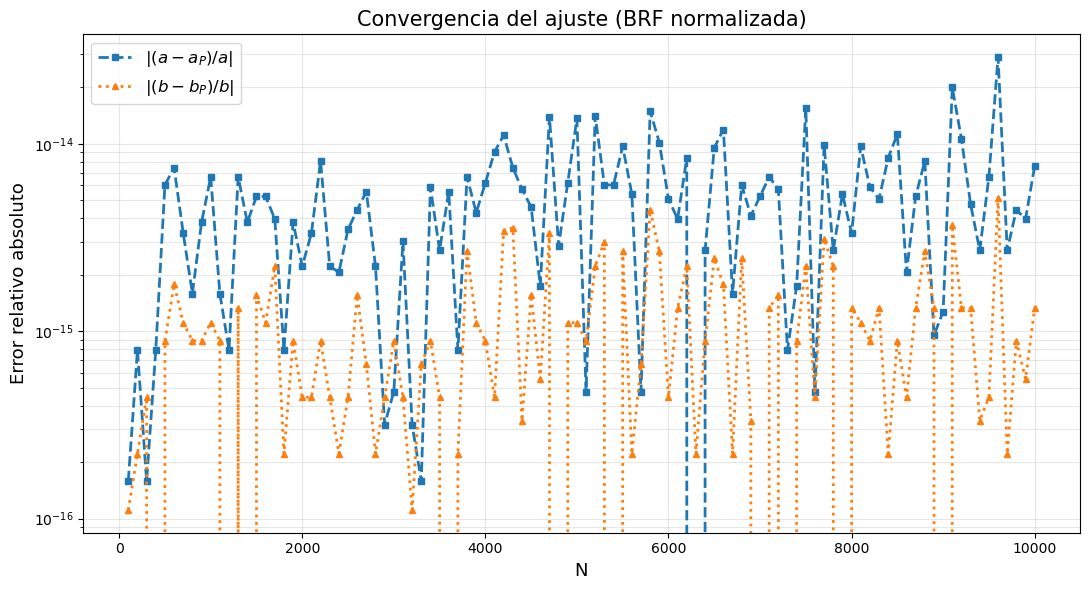

In [137]:
res, pars = experimento_convergencia_N(
    100,
    usar_BRF=True,
    normalizado=True
)

plot_convergencia_N(

    res,

    usar_BRF=True,

    normalizado=True

)

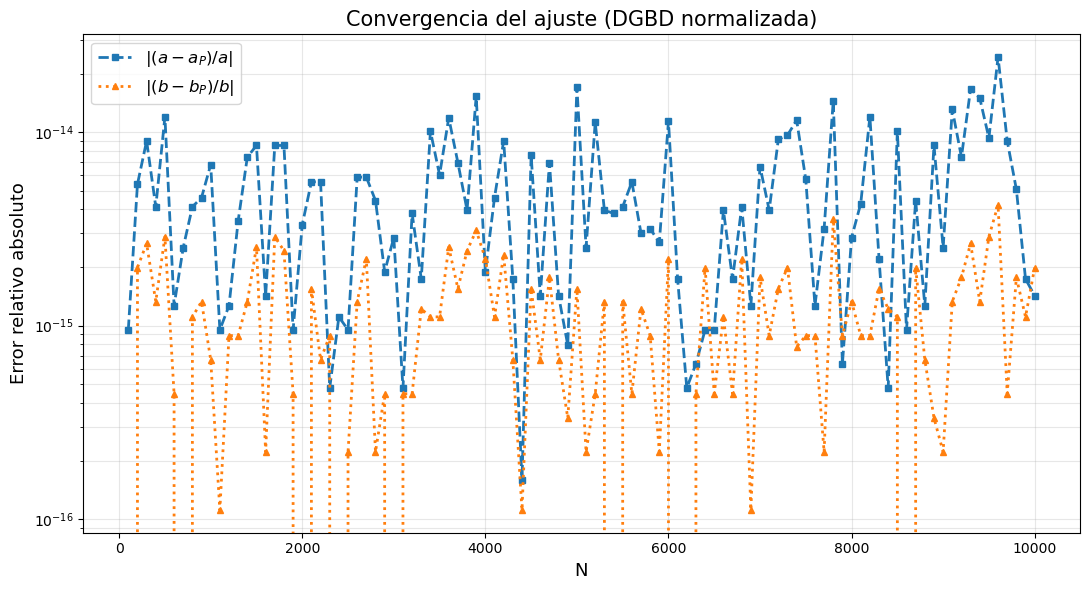

In [138]:
res, pars = experimento_convergencia_N(
    100,
    usar_BRF=False,
    normalizado=True
)
plot_convergencia_N(

    res,

    usar_BRF=False,

    normalizado=True

)

### Precisión del ajuste y cálculo de cumulantes teóricos

Los experimentos de convergencia realizados sobre la región normalizable de parámetros muestran que el error relativo en la recuperación de los exponentes $a$ y $b$ decrece rápidamente conforme aumenta el tamaño del sistema. En particular, para valores tan modestos como

$$
N \gtrsim 100,
$$

los errores relativos típicamente alcanzan magnitudes del orden de

$$
10^{-15}\text{--}10^{-14},
$$

es decir, valores comparables a la precisión numérica de doble precisión utilizada en los cálculos.

Estos resultados indican que, dentro de la región admisible

$$
a<1,
\qquad
b>-1,
$$

el procedimiento de ajuste recupera los parámetros originales con una precisión prácticamente exacta. En consecuencia, la incertidumbre introducida por el ajuste es despreciable frente a cualquier otra fuente de error presente en el análisis.

Desde esta perspectiva, resulta natural utilizar directamente los parámetros obtenidos mediante el ajuste para evaluar las expresiones teóricas de los cumulantes,

$$
k_n = k_n(a,b),
$$

sin necesidad de calcular cumulantes empíricos ni de compararlos posteriormente con sus contrapartes teóricas. Dado que los exponentes recuperados coinciden con los parámetros reales hasta errores cercanos a la precisión de máquina, ambas estrategias producen resultados indistinguibles en la práctica.

Por lo tanto, una vez verificada la estabilidad del ajuste, el cálculo de cumulantes puede simplificarse considerablemente: basta ajustar la distribución para obtener $(a,b)$ y sustituir dichos valores en las expresiones analíticas de los cumulantes. Esto evita introducir ruido estadístico asociado a la estimación empírica y permite explotar directamente la información contenida en la forma funcional de la distribución.

En otras palabras, para tamaños del sistema del orden de

$$
N \ge 100,
$$

la cadena

$$
\text{Datos}
\;\longrightarrow\;
(a,b)
\;\longrightarrow\;
k_n^{\mathrm{teórico}}
$$

puede considerarse equivalente, dentro de la precisión numérica disponible, al procedimiento más costoso

$$
\text{Datos}
\;\longrightarrow\;
k_n^{\mathrm{empírico}}
\;\longrightarrow\;
k_n^{\mathrm{teórico}}.
$$

Los resultados obtenidos sugieren que el ajuste paramétrico constituye una representación suficientemente precisa de la distribución como para reemplazar completamente el cálculo de cumulantes empíricos en la región normalizable estudiada.

In [142]:
def robustez_vs_N(
    usar_BRF=True,
    normalizado=True
):

    a_real = 0.7
    b_real = 0.5

    Ns = [100, 300, 1000, 3000, 10000]

    ruidos = [1e-10, 1e-8, 1e-6, 1e-4, 1e-2]

    n_reps = 100

    rng = np.random.default_rng(1234)

    resultados_a = {}
    resultados_b = {}

    for eps in ruidos:

        sigma_a = []
        sigma_b = []

        print(f"Ruido = {eps}")

        for N in Ns:

            # ==========================================
            # Distribución exacta
            # ==========================================
            if usar_BRF:

                pdf = BRF(
                    N,
                    A=1.0,
                    a=a_real,
                    b=b_real,
                    normalizar=normalizado
                )

            else:

                pdf = DGBD(
                    N,
                    A=1.0,
                    a=a_real,
                    b=b_real,
                    normalizar=normalizado
                )

            a_fit_all = []
            b_fit_all = []

            for _ in range(n_reps):

                # --------------------------------------
                # Ruido multiplicativo
                # --------------------------------------
                ruido = (
                    1.0
                    + eps * rng.standard_normal(N)
                )

                pdf_r = pdf * ruido

                pdf_r = np.clip(
                    pdf_r,
                    1e-300,
                    None
                )

                if normalizado:
                    pdf_r /= np.sum(pdf_r)

                # --------------------------------------
                # Ajuste
                # --------------------------------------
                if normalizado:

                    a_fit, b_fit = fit_rank_normalizado(
                        pdf_r,
                        usar_BRF=usar_BRF
                    )

                else:

                    _, a_fit, b_fit = fit_rank(
                        pdf_r,
                        usar_BRF=usar_BRF
                    )

                a_fit_all.append(a_fit)
                b_fit_all.append(b_fit)

            sigma_a.append(
                np.std(a_fit_all)
            )

            sigma_b.append(
                np.std(b_fit_all)
            )

        resultados_a[eps] = sigma_a
        resultados_b[eps] = sigma_b

    # ==========================================
    # GRAFICAS
    # ==========================================

    modelo = "BRF" if usar_BRF else "DGBD"

    if normalizado:
        modelo += " normalizada"

    fig, ax = plt.subplots(
        1,
        2,
        figsize=(13, 5)
    )

    # --------------------------------------
    # sigma(a)
    # --------------------------------------
    for eps in ruidos:

        ax[0].plot(
            Ns,
            resultados_a[eps],
            marker="o",
            linewidth=2,
            label=f"ε={eps:.0e}"
        )

    ax[0].set_xscale("log")
    ax[0].set_yscale("log")

    ax[0].set_xlabel("N")
    ax[0].set_ylabel(r"$\sigma(a)$")

    ax[0].set_title(
        f"Robustez de a ({modelo})"
    )

    ax[0].grid(
        True,
        which="both",
        alpha=0.3
    )

    ax[0].legend()

    # --------------------------------------
    # sigma(b)
    # --------------------------------------
    for eps in ruidos:

        ax[1].plot(
            Ns,
            resultados_b[eps],
            marker="s",
            linewidth=2,
            label=f"ε={eps:.0e}"
        )

    ax[1].set_xscale("log")
    ax[1].set_yscale("log")

    ax[1].set_xlabel("N")
    ax[1].set_ylabel(r"$\sigma(b)$")

    ax[1].set_title(
        f"Robustez de b ({modelo})"
    )

    ax[1].grid(
        True,
        which="both",
        alpha=0.3
    )

    ax[1].legend()

    plt.tight_layout()
    plt.show()

    return resultados_a, resultados_b

Ruido = 1e-10
Ruido = 1e-08
Ruido = 1e-06
Ruido = 0.0001
Ruido = 0.01


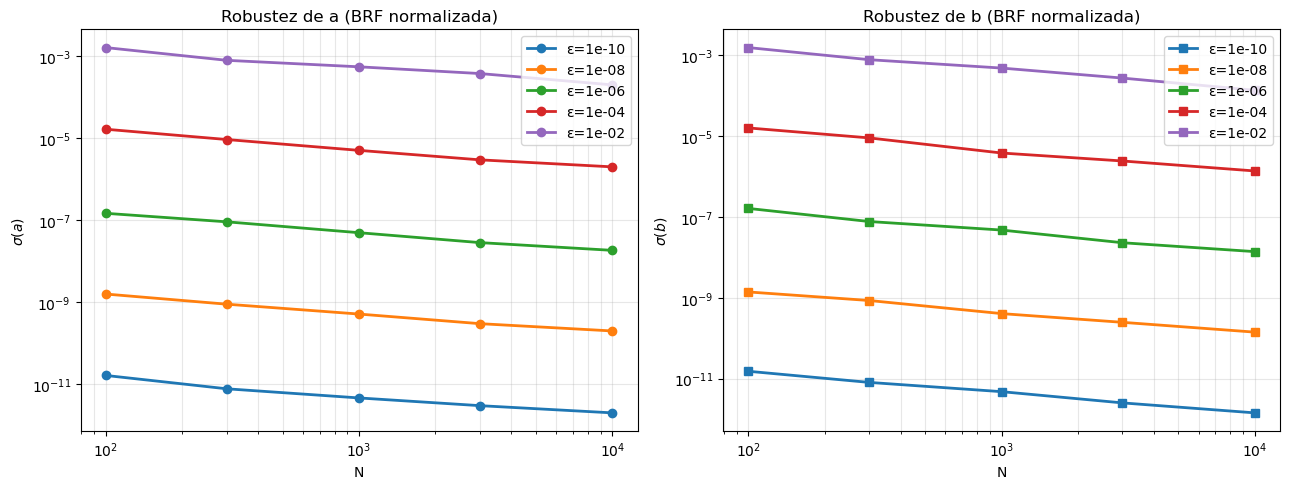

({1e-10: [np.float64(1.613750976896779e-11),
   np.float64(7.641740447048063e-12),
   np.float64(4.572485186981269e-12),
   np.float64(2.966342200796575e-12),
   np.float64(1.9797213299022147e-12)],
  1e-08: [np.float64(1.5554570545636398e-09),
   np.float64(8.809726996505164e-10),
   np.float64(5.062177057285431e-10),
   np.float64(2.9539116799512936e-10),
   np.float64(1.9627065078355191e-10)],
  1e-06: [np.float64(1.443332307977755e-07),
   np.float64(8.95824073592166e-08),
   np.float64(4.863512304490854e-08),
   np.float64(2.7906956469523173e-08),
   np.float64(1.807968930317511e-08)],
  0.0001: [np.float64(1.6148110391316234e-05),
   np.float64(9.075197618915054e-06),
   np.float64(4.938382914335201e-06),
   np.float64(2.902528700022363e-06),
   np.float64(1.9584741532203663e-06)],
  0.01: [np.float64(0.0015781219973964096),
   np.float64(0.0007729970035750915),
   np.float64(0.0005368850841168234),
   np.float64(0.0003679156901899733),
   np.float64(0.00019500931271158108)]},
 {

In [143]:
robustez_vs_N(
    usar_BRF=True,
    normalizado=True
)

Ruido = 1e-10
Ruido = 1e-08
Ruido = 1e-06
Ruido = 0.0001
Ruido = 0.01


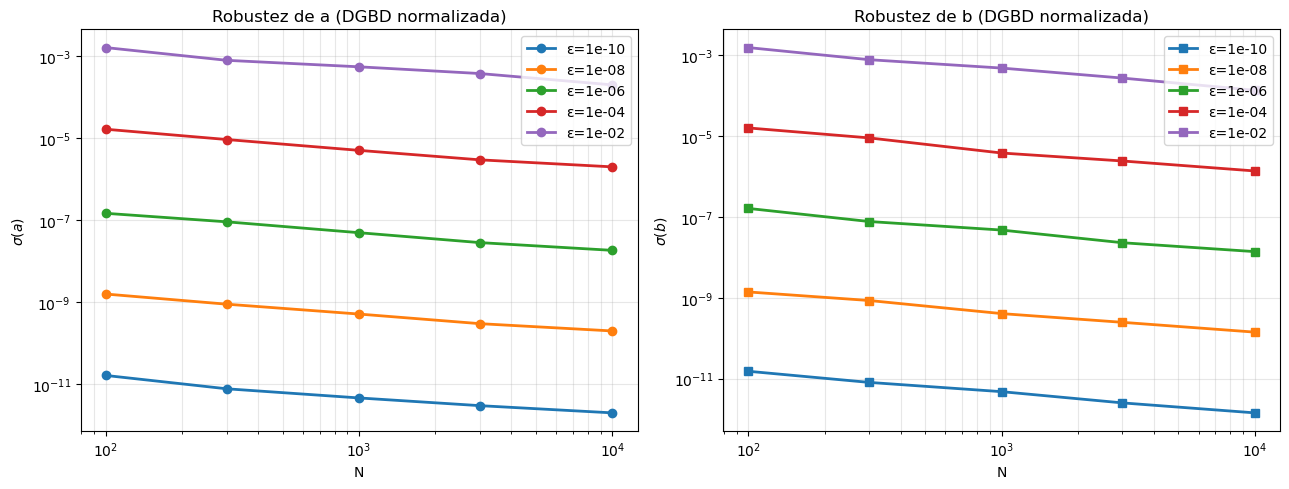

({1e-10: [np.float64(1.613750273205703e-11),
   np.float64(7.641734819724064e-12),
   np.float64(4.57252898320983e-12),
   np.float64(2.966317683461769e-12),
   np.float64(1.979662214555568e-12)],
  1e-08: [np.float64(1.5554570754044996e-09),
   np.float64(8.809726909549797e-10),
   np.float64(5.062177122881502e-10),
   np.float64(2.9539115949627606e-10),
   np.float64(1.9627065936173752e-10)],
  1e-06: [np.float64(1.443332306951953e-07),
   np.float64(8.958240764602379e-08),
   np.float64(4.8635123086854475e-08),
   np.float64(2.7906956345921147e-08),
   np.float64(1.8079689248117917e-08)],
  0.0001: [np.float64(1.6148110409387042e-05),
   np.float64(9.07519759676293e-06),
   np.float64(4.938383139814668e-06),
   np.float64(2.902529302808801e-06),
   np.float64(1.9584741073893583e-06)],
  0.01: [np.float64(0.0015781220156216825),
   np.float64(0.0007729969976747354),
   np.float64(0.0005368850802867547),
   np.float64(0.00036791569040981267),
   np.float64(0.00019500931470083945)]},
 

In [144]:
robustez_vs_N(
    usar_BRF=False,
    normalizado=True
)

### Robustez del ajuste frente a ruido multiplicativo

Con el objetivo de evaluar la estabilidad del procedimiento de ajuste, se estudió el efecto de introducir ruido multiplicativo en distribuciones BRF y DGBD generadas a partir de parámetros conocidos. Para cada tamaño del sistema $N$, se construyeron múltiples realizaciones independientes de la distribución perturbada y posteriormente se ajustaron los parámetros $a$ y $b$.

El ruido se introdujo mediante la transformación

$$
x_i \longrightarrow x_i\,(1+\epsilon \eta_i),
$$

donde

$$
\eta_i \sim \mathcal N(0,1)
$$

es una variable aleatoria gaussiana y $\epsilon$ controla la intensidad del ruido.

A diferencia del ruido aditivo, el ruido multiplicativo modifica cada valor de manera proporcional a su magnitud original. Este tipo de perturbación resulta especialmente relevante en distribuciones de rango, ya que preserva la estructura general de la señal mientras introduce fluctuaciones relativas controladas.

Se analizaron niveles de ruido comprendidos entre

$$
\epsilon = 10^{-10}
\quad\text{y}\quad
\epsilon = 10^{-2}.
$$

Para cada combinación de $N$ y $\epsilon$, se realizaron múltiples ajustes independientes y se estudió la dispersión de los parámetros recuperados.

### Interpretación de $\sigma$

La cantidad representada en las gráficas es la desviación estándar

$$
\sigma(a)
\qquad\text{y}\qquad
\sigma(b),
$$

calculada a partir de todos los valores obtenidos durante las repeticiones del experimento.

De forma intuitiva, $\sigma$ mide cuánto varían los parámetros ajustados al repetir el procedimiento bajo diferentes realizaciones del ruido. Valores pequeños de $\\sigma$ indican que el ajuste es estable y reproduce prácticamente los mismos parámetros incluso cuando los datos son perturbados.

### Resultados observados

Los resultados muestran una elevada robustez del procedimiento de ajuste. Incluso para el mayor nivel de ruido considerado,

$$
\epsilon = 10^{-2},
$$

las fluctuaciones observadas en los parámetros recuperados son muy reducidas.

En particular, para tamaños tan pequeños como

$$
N = 100,
$$

las desviaciones estándar permanecen típicamente alrededor de

$$
\sigma \sim 10^{-3},
$$

a pesar de que el ruido introducido es varios órdenes de magnitud mayor.

Además, al incrementar el tamaño del sistema, la dispersión disminuye sistemáticamente. Esto indica que la información adicional contenida en distribuciones más largas compensa de manera eficiente las perturbaciones introducidas por el ruido.

En términos prácticos, el ajuste se vuelve progresivamente más estable conforme aumenta $N$, incluso cuando la intensidad del ruido permanece fija.

### Conclusión

Los experimentos muestran que tanto la BRF como la DGBD presentan una notable estabilidad frente a ruido multiplicativo. Incluso bajo perturbaciones relativamente grandes ($\epsilon=10^{-2}$), las fluctuaciones de los parámetros ajustados permanecen pequeñas y disminuyen al aumentar el tamaño del sistema. Estos resultados sugieren que el procedimiento de ajuste es suficientemente robusto para recuperar los exponentes característicos de la distribución incluso en presencia de niveles apreciables de ruido.

### Equivalencia práctica entre BRF y DGBD

Los distintos experimentos realizados a lo largo de este trabajo muestran que las diferencias observadas entre la BRF y la DGBD no tienen un impacto práctico en la recuperación de los parámetros ni en los cumulantes obtenidos a partir de ellos.

En particular, se verificó que:

- Ambas expresiones describen la misma familia funcional una vez que se tiene en cuenta el cambio de variables

$$
u=\frac{r}{N+1},
$$

y la relación

$$
\mathrm{BRF}(u)
=
A\,
\frac{(1-u)^b}{u^a},
$$

$$
\mathrm{DGBD}(r)
=
A\,
\frac{(N+1-r)^b}{r^a}.
$$

- Los ajustes recuperan los mismos exponentes $a$ y $b$ dentro de la precisión numérica disponible.

- Los errores relativos observados en la estimación de los parámetros alcanzan valores del orden de

$$
10^{-15}\text{--}10^{-14},
$$

lo que corresponde esencialmente a precisión de máquina.

- Los cumulantes teóricos calculados a partir de los parámetros ajustados son indistinguibles entre ambas representaciones cuando se utilizan las expresiones consistentes con cada formulación.

Por lo tanto, una vez establecida la correspondencia entre ambas distribuciones, deja de ser especialmente relevante decidir si el análisis se realiza utilizando BRF o DGBD. Ambas constituyen representaciones equivalentes de la misma estructura matemática y conducen a los mismos resultados físicos y estadísticos dentro de la precisión numérica alcanzable.

Lo verdaderamente importante es mantener la consistencia interna del procedimiento. Es decir, si se decide trabajar con una de las dos representaciones, deben emplearse de manera coherente las expresiones asociadas a dicha formulación en todas las etapas del análisis:

- generación de datos;
- normalización;
- ajuste de parámetros;
- cálculo de cumulantes teóricos;
- evaluación de errores;
- comparación con resultados empíricos.

En consecuencia, cualquiera de las dos representaciones puede utilizarse como punto de partida. La elección entre BRF y DGBD pasa a ser principalmente una cuestión de conveniencia o preferencia de notación, siempre que las fórmulas empleadas en cada etapa correspondan a la representación elegida.

In [ ]:
def cumulantes_teoricos_normalizados(N, a, b, f=False):
    zeta3 = 1.202056903159594
    r = np.arange(1, N + 1)
    if f:   # BRF
        u = r/(N+1)
        Z = np.sum(((1-u)**b)/(u**a))
        k1 = -np.log(Z) + a - b
    else:   # DGBD
        Z = np.sum(((N+1-r)**b)/(r**a))
        k1 = ((b-a)/N)*gammaln(N+1) - np.log(Z)
     
    k2 = (a - b) ** 2 + (np.pi**2 / 3) * a * b
    k3 = 2 * zeta3 * (a**3 - b**3) + 2 * (zeta3 - 1) * (b - a) ** 3
    k4 = (np.pi**4 / 15) * (a**4 + b**4 - (b - a) ** 4) + 6 * (b - a) ** 4

    return np.array([k1, k2, k3, k4])

In [ ]:
print(DGBD(700, 108, 0.0238, 0.0285, normalizar=False)) #Prueba de que se pueden generar datos de cardio, sin necesidad de la PDF (datos presión)

[130.16944394 128.03445026 126.79967756 125.92932105 125.25718081
 124.70972532 124.24793144 123.84860267 123.49682928 123.18246198
 122.89828108 122.63896867 122.40049501 122.17973399 121.97421193
 121.78193805 121.60128661 121.43091288 121.26969197 121.11667349
 120.97104723 120.83211694 120.69927995 120.57201114 120.44985017
 120.33239131 120.21927511 120.11018162 120.00482485 119.90294811
 119.80432016 119.70873193 119.61599381 119.52593331 119.43839302
 119.35322897 119.27030909 119.18951195 119.11072567 119.03384692
 118.95878008 118.8854365  118.81373383 118.74359544 118.67494991
 118.60773055 118.541875   118.4773249  118.4140255  118.35192539
 118.29097623 118.23113255 118.17235146 118.11459251 118.05781749
 118.00199026 117.94707662 117.89304417 117.83986218 117.78750148
 117.73593434 117.68513442 117.63507664 117.5857371  117.53709303
 117.48912272 117.44180543 117.39512135 117.34905155 117.30357791
 117.2586831  117.21435051 117.17056423 117.127309   117.08457016
 117.04233